In [ ]:
# Example loading and plotting lidar data of Hybrid Dune Campaign

import numpy as np 
import xarray as xr
import os   
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib as mpl
import colorcet as cc   # For color maps
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from netCDF4 import Dataset
import warnings

import sys
sys.path.append('../functions')
from convert_lidar_coordinates_ds_single import convert_lidar_coordinates_ds


In [7]:
## 1) FUNCTION TO LOAD AND FILTER LIDAR DATA
def filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=None, profile_isel=None, i_obs_start=361, i_obs_end=545):
    # Load pointcloud and convert to local coordinates. Filter cloud by deleting the mounting frame from the cloud, as well as high points that are waves/rain/...  
    # i_obs_start = 361  is straight under the lidar. i_obs_start = 545 for the later storms, when the dune toe is further seaward. i_obs_end = 545 # for 93deg

    # Define frame angles to be skipped
    # Initialize the array: shape (3, 2, 4, 3) for 3 skip_regions × 2 limits (start_stop) × 4 lidars × 3 storms
    hoek_frame_skip = np.zeros((3, 2, 4, 3))
    # S1
    hoek_frame_skip[:, :, 0, 0] = [[-17.4, -14.9], [-13.8, -10.9], [-2.75, 0]]   # storm 1
    hoek_frame_skip[:, :, 0, 1] = [[-16.9, -13.9], [-13.3, -9.9], [-2.25, 0.5]]  # storm 2
    hoek_frame_skip[:, :, 0, 2] = [[-17.4, -14.4], [-13.8, -10.9], [-2.75, 0]]   # storm 3

    # S2
    hoek_frame_skip[:, :, 1, 0] = [[-21.2, -18.2], [-14.3, -11.3], [-2.3, 0.7]]
    hoek_frame_skip[:, :, 1, 1] = [[-20.2, -17.7], [-13.8, -10.8], [-1.3, 1.7]]
    hoek_frame_skip[:, :, 1, 2] = [[-21.2, -18.2], [-14.3, -11.8], [-2.3, 0.7]]

    # S3
    hoek_frame_skip[:, :, 2, 0] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 1] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 2] = [[-17.5, -14.5], [-12.5, -10.0], [0.5, 4.0]]

    # S4
    hoek_frame_skip[:, :, 3, 0] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 1] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 2] = [[-19.75, -16.75], [-11.75, -8.75], [-3.25, -0.25]]

        # # determine limits to load data from: which vertical angles to select. Between -90° and 105°
        # ds = xr.open_dataset(nc_in).isel(profile_number=0, t=0, echos=0)   # select specific time range: t0 until t_end

        # # # find obs_number with -90° < beam_angle < 105°
        # i_obs_start = np.where(ds.beam_angle.values > -90)[0][0]
        # i_obs_end = np.where(ds.beam_angle.values < 93)[0][-1]
        # print(i_obs_end)



    # load data with these obs_number limits
    if (t_sel is  None) and (profile_isel is None):
        ds = xr.open_dataset(nc_in).isel(obs_number=slice(i_obs_start, i_obs_end))                                            # select specific angles
    elif t_sel is None:
        ds = xr.open_dataset(nc_in).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))               # select specific angles and profile
    elif profile_isel is None:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(obs_number=slice(i_obs_start, i_obs_end))                               # select specific angles and time range
    else:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))  # select specific angles, profile and time range

    # Filter out the frame -----------------------------------------------------------------------
    # Filter out the frame by replacing values in ds.beam_angle with NaN where the laser sees the frame. Then use filtered beam angles for coordinate conversion.

    # Select the slice for given n_lidar and n_storm (Python: 0-based)
    # Example: n_lidar = 1, n_storm = 2 (MATLAB) -> Python: 0, 1
    hoek_frame_skip_slice = hoek_frame_skip[:, :, n_lidar-1, n_storm-1] 

    # Filter frame: loop, for every row in hoek_frame_skip_slice, make angles nan where angles>value_col_1 and angles<value_col_2
    angles = ds.beam_angle.values

    for row in hoek_frame_skip_slice:
        angles[(angles > row[0]) & (angles < row[1])] = np.nan

    ds.beam_angle.values = angles   

    # Convert to local coordinates
    ds = convert_lidar_coordinates_ds(ds, 'local', max_echos=True, keep_I=True, keep_r=True, keep_y=False) # skip intensity, take max distance of echos

    # Define skip area (to remove points below x=6m and above z=-1m)
    x_skip_area = 6.5   # delete every point that is less than 6 m landward of lidar, and (simultaneously) less than 1 m below the lidar
    z_skip_area = -1
    x_min = ds.x_i_local.values + x_skip_area
    z_max = ds.z_i.values + z_skip_area

    # make x, y, z values nan where (x < x_skip_area) & (z > z_skip_area)
    mask_keep = (ds.x.values > x_min) | (ds.z.values < z_max) # keep where either condition is met. So remove where <x_lmin and >z_max
    ds['x'] = ds.x.where(mask_keep)
    #ds['y'] = ds.y.where(mask_keep)
    ds['z'] = ds.z.where(mask_keep)
    ds['radius_lidar'] = ds.radius_lidar.where(mask_keep)
    ds['intensity'] = ds.intensity.where(mask_keep)

    return ds


In [8]:
def filtered_mean_remove_smallest(windows, std_thr=0.01, min_keep_frac=0.5):
    """
    Remove smallest values iteratively (per window along last axis) until std <= std_thr.
    Return mean of remaining values; return NaN if too many values were removed.

    Parameters
    ----------
    windows : np.ndarray
        Any shape (..., L). Filtering is done along the last axis only.
    std_thr : float
        Threshold for population std (ddof=0), e.g. 0.01.
    min_keep_frac : float
        Minimum fraction of values that must remain. If fewer remain, output NaN.

    Returns
    -------
    out : np.ndarray
        Shape windows.shape[:-1], containing filtered means.
    """

    # NB: effectively a faster, vectorized version of this loop-based approach:
    # r_filter_v2 = r_mean_5s.copy()
    # for i in range(n_obs):
    #     for j in range(n_win):
    #         window = windows[i, j, :].copy()
    #         while np.nanstd(window) > 0.01 and np.count_nonzero(~np.isnan(window)) > 0:
    #             # remove the smallest (non-NaN) value
    #             try:
    #                 idx_to_remove = np.nanargmin(window)
    #             except ValueError:
    #                 break
    #             window[idx_to_remove] = np.nan
    #         r_filter_v2[i, j] = np.nanmean(window)

    #         if np.count_nonzero(~np.isnan(window)) < win_len / 2:
    #             r_filter_v2[i, j] = np.nan
    
    W0 = np.asarray(windows, dtype=float)
    if W0.ndim < 1:
        raise ValueError("`windows` must have at least 1 dimension.")

    L = W0.shape[-1]
    leading_shape = W0.shape[:-1]
    N = int(np.prod(leading_shape)) if leading_shape else 1

    # Flatten only leading dims; keep last dim as window length
    W = W0.reshape(N, L)

    valid = np.isfinite(W)
    n_valid = valid.sum(axis=1)

    # Sort once per window; NaNs -> +inf so they move to the end
    W_sort = np.sort(np.where(valid, W, np.inf), axis=1)
    finite_sorted = np.isfinite(W_sort)
    X = np.where(finite_sorted, W_sort, 0.0)

    # Prefix sums (with leading zero)
    cs = np.concatenate([np.zeros((N, 1)), np.cumsum(X, axis=1)], axis=1)
    cs2 = np.concatenate([np.zeros((N, 1)), np.cumsum(X * X, axis=1)], axis=1)

    total = cs[:, -1]
    total2 = cs2[:, -1]

    # k = number of removed smallest values
    k = np.arange(L + 1)[None, :]      # (1, L+1)
    m = n_valid[:, None] - k           # remaining count after removing k smallest

    # Remaining sums after removing k smallest values
    sum_rem = total[:, None] - cs[:, :L+1]
    sumsq_rem = total2[:, None] - cs2[:, :L+1]

    with np.errstate(invalid="ignore", divide="ignore"):
        mean_rem = sum_rem / m
        var_rem = sumsq_rem / m - mean_rem * mean_rem
    std_rem = np.sqrt(np.maximum(var_rem, 0.0))

    min_keep = int(np.ceil(min_keep_frac * L))
    good = (m >= min_keep) & np.isfinite(std_rem) & (std_rem <= std_thr)

    has_solution = good.any(axis=1)
    k_star = np.where(has_solution, good.argmax(axis=1), -1)

    out = np.full(N, np.nan, dtype=float)
    rows = np.where(has_solution)[0]
    out[rows] = mean_rem[rows, k_star[rows]]

    return out.reshape(leading_shape)

In [209]:
## 2) LOAD AND FILTER LIDAR DATA
# INPUT PARAMETERS ------------------------------------------------------------------------------------------------
n_lidar = 2  # set as needed (1-based, like MATLAB)
i_obs_start_all = [420, 500, 500] # for 3 storms
for n_storm in [2]: #[1, 2, 3]:
#n_storm = 1 # set as needed (1-based, like MATLAB)

    nc_in = fr"C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Lidar\data\S{n_lidar} Lidar, storm{n_storm}.nc"
    if n_storm == 1:
        t1 = pd.Timestamp('19-12-2024 00:02') # was 2:00
        t2 = pd.Timestamp('19-12-2024 22:00') # was 19dec 22:00
    elif n_storm == 2:
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:10')
        t1 = pd.Timestamp('22-12-2024 07:30')
        t2 = pd.Timestamp('22-12-2024 08:30')
        t1 = pd.Timestamp('22-12-2024 07:00')
        t2 = pd.Timestamp('22-12-2024 10:30')
    elif n_storm == 3:
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')

    # LOAD AND FILTER POINTCLOUD ----------------------------------------------------------------------------------------
    i_obs_start = i_obs_start_all[n_storm-1] # Python: 0-based indexing
    ds = filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=slice(t1, t2), profile_isel=2, i_obs_start=i_obs_start ) # Filter out frame and high waves (points less than 1 m below lidar and offshore of dune toe)    
    #ds = ds.drop_vars(['x','z'])




In [210]:
# MAKE T SPACING EXACTLY 0.25S ------------------------------------------------------------------------------------------
# Times are snapped to the nearest 0.25s, times without nearby value get nan. No interpolation/resampling is done. So timeseries get distorted slightly, but that does not matter for profiles, where we look at moving averages etc anyway. 
t = pd.to_datetime(ds.t.values)                                                         # original time values
t_new = pd.date_range(t.min().ceil("250ms"), t.max().floor("250ms"), freq="250ms")      # uniform time grid with 0.25s spacing
idx = pd.Index(t_new).get_indexer(t, method="nearest")                                  # Compute nearest indices for t on target grid

r_new = xr.DataArray( np.full((ds.sizes["obs_number"], len(t_new)), np.nan),            # build empty array for r with uniform time spacing
                      dims=("obs_number", "t"),
                      coords={"obs_number": ds.obs_number, "t": t_new}   )
r_new.values[:, idx] = ds.radius_lidar.values                                           # fill. If collisions happen, later ones overwrite earlier ones
I_new = xr.DataArray( np.full((ds.sizes["obs_number"], len(t_new)), np.nan),            # build empty array for I with uniform time spacing
                      dims=("obs_number", "t"),
                      coords={"obs_number": ds.obs_number, "t": t_new}   )
I_new.values[:, idx] = ds.intensity.values                                           # fill. If collisions happen, later ones overwrite earlier ones

# update ds in-place
ds = ds.drop_dims("t")
ds = ds.assign_coords(t=t_new)
ds["radius_lidar"] = r_new
ds["intensity"] = I_new

ds = convert_lidar_coordinates_ds(ds, 'local', max_echos=False, keep_I=True, keep_r=True, keep_y=False) # Recalculate x, z. Effectively the same as updating x and z with the new t-coordinate. 

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_9988\3294271362.py:6: UserWarning: sf = 0.1 instead of 4. Correct NetCDF! Using sf=4 for now
  warnings.warn(f"sf = {sf} instead of 4. Correct NetCDF! Using sf=4 for now")


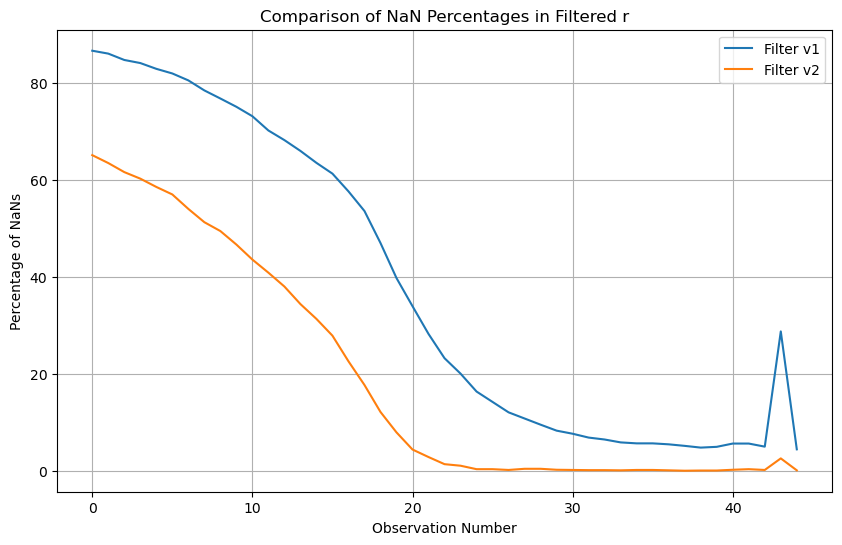

In [211]:
## FILTER OVER 5s WINDOW

# Settings ------------------------------------------------------------------------------------------------------
sf = float(ds.sf.values)
if sf != 4.0:   # Temp code: sampling frequency of storm 2, lidar 2 is incorrect, at 0.1 Hz instead of 4 Hz
    warnings.warn(f"sf = {sf} instead of 4. Correct NetCDF! Using sf=4 for now")
    sf = 4
win_len = int(5 * sf)   # 5s in samples
step = int(5 * sf)      # 5s in samples

# Build strided window view of r, for fast computation of percentiles over the windows.---------------------------
#r = ds.radius_lidar.transpose("obs_number", "t")  # ensure shape is (obs_number, t)
arr = ds.radius_lidar.values
n_obs, n_t = arr.shape

# number of windows
n_win = (n_t - win_len) // step + 1
if n_win <= 0:
    raise ValueError("Not enough samples for a 10-min window.")

# build strided window view: (obs_number, window, sample)
s0, s1 = arr.strides
windows = np.lib.stride_tricks.as_strided( arr,
                                           shape=(n_obs, n_win, win_len),
                                           strides=(s0, step * s1, s1),
                                           writeable=False )

# Calculate the median and standard deviation over the window samples
r_mean_5s = np.mean(windows, axis=2)  # shape (obs_number, n_win)
r_std_5s = np.std(windows, axis=2)     # shape (obs_number, n_win)

# filter v1: set mean to nan where std exceeds 1cm, so that we only keep windows where r is stable
r_filter_v1 = r_mean_5s.copy()  # shape (obs_number, n_win)
r_filter_v1[r_std_5s > 0.01] = np.nan

# filter v2: if std>1cm, iteratively remove smallest r until std<1cm. If 50% of values are removed, r_filtered=NaN
r_filter_v2 = filtered_mean_remove_smallest(windows, std_thr=0.01, min_keep_frac=0.5)

# calculate filtered I
arr = ds.intensity.values
s0, s1 = arr.strides
windows = np.lib.stride_tricks.as_strided( arr,
                                           shape=(n_obs, n_win, win_len),
                                           strides=(s0, step * s1, s1),
                                           writeable=False )
I_filter_v1 = np.nanmean(windows, axis=2)  # shape (obs_number, n_win)
I_filter_v1[r_std_5s > 0.01] = np.nan

I_filter_v2 = np.nanmean(windows, axis=2)  # shape (obs_number, n_win)
I_filter_v2[np.isnan(r_filter_v2)] = np.nan

# make a plot to compare the percentage of nan in v1 and v2 per obs_number
nan_percentage_v1 = np.sum(np.isnan(r_filter_v1), axis=1) / n_win * 100
nan_percentage_v2 = np.sum(np.isnan(r_filter_v2), axis=1) / n_win * 100
plt.figure(figsize=(10, 6))
plt.plot(ds.obs_number.values[:n_obs], nan_percentage_v1, label="Filter v1")
plt.plot(ds.obs_number.values[:n_obs], nan_percentage_v2, label="Filter v2")
plt.xlabel("Observation Number")
plt.ylabel("Percentage of NaNs")
plt.title("Comparison of NaN Percentages in Filtered r")
plt.legend()
plt.grid()
plt.show()

In [212]:
# center times for each window
t_vals = pd.to_datetime(ds.t.values)
center_idx = np.arange(n_win) * step + win_len // 2
t_center = t_vals[center_idx].round('0.5s')  

# wrap back to xarray
r_filter_v1 = xr.DataArray( r_filter_v1,  dims=("obs_number", "t_window"),  coords={"obs_number": ds.obs_number, "t_window": t_center}  )
r_filter_v2 = xr.DataArray( r_filter_v2,  dims=("obs_number", "t_window"),  coords={"obs_number": ds.obs_number, "t_window": t_center}  )
I_filter_v1 = xr.DataArray( I_filter_v1,  dims=("obs_number", "t_window"),  coords={"obs_number": ds.obs_number, "t_window": t_center}  )
I_filter_v2 = xr.DataArray( I_filter_v2,  dims=("obs_number", "t_window"),  coords={"obs_number": ds.obs_number, "t_window": t_center}  )

# Save result to Xarray Dataset --------
# Define a new ds_profiles: a copy of ds, without the coordinate t, and with r_final as radius_lidar
ds_filter_v1 = ds.drop_dims("t")  # drop t dimension
ds_filter_v2 = ds.drop_dims("t")  # drop t dimension

ds_filter_v1['radius_lidar'] = r_filter_v1  # Assign r_final as the new radius_lidar. Var name must be radius_lidar for convert_lidar_coordinates_ds
ds_filter_v1['intensity'] = I_filter_v1  # Assign I_final as the new intensity. Var name must be intensity for convert_lidar_coordinates_ds
ds_filter_v2['radius_lidar'] = r_filter_v2  # Assign r_final as the new radius_lidar. Var name must be radius_lidar for convert_lidar_coordinates_ds
ds_filter_v2['intensity'] = I_filter_v2      # WARNING: INTENSITY BASED ON FULL WINDOW, NO ITERATION APPLIED ************************************************************

ds_filter_v1 = convert_lidar_coordinates_ds(ds_filter_v1, 'local', max_echos=False, keep_I=True, keep_r=True, keep_y=False) # skip intensity. Max echos already taken, not needed again
ds_filter_v2 = convert_lidar_coordinates_ds(ds_filter_v2, 'local', max_echos=False, keep_I=True, keep_r=True, keep_y=False) # skip intensity. Max echos already taken, not needed again

In [ ]:
# Filter v3: remove all profiles where 
# - the first nonnan value of x > 796
# - the largest difference dL (dx^2 + dz^2)^(1/2) between consecutive points exceeds 0.5 m
ds_filter_v3 = ds_filter_v2.copy(deep=True)

# settings
if n_storm == 1:
    x_min = 792
else:
    x_min = 796


for i in range(n_win):
    x = ds_filter_v3.x.values[:, i]  # shape (obs_number,)
    z = ds_filter_v3.z.values[:, i]  # shape (obs_number,)

    # extract non_nan values
    non_nan_mask = ~np.isnan(x) & ~np.isnan(z)
    x_non_nan = x[non_nan_mask]
    z_non_nan = z[non_nan_mask]

    if len(x_non_nan) == 0:
        continue
    if x_non_nan[0] > x_min:
        ds_filter_v3.radius_lidar.values[:, i] = np.nan
        ds_filter_v3.x.values[:, i] = np.nan
        ds_filter_v3.z.values[:, i] = np.nan
        ds_filter_v3.intensity.values[:, i] = np.nan
        continue

    mask_keep = (x_non_nan > x_min) & (z_non_nan < 4.5)  # keep points that are landward of 796 and below the crest
    mask_keep[:-1] |= mask_keep[1:]       # set previous neighbour true where next is true: keep last point before x=796
    mask_keep[1:]  |= mask_keep[:-1]      # set next neighbour true where previous is true: keep last point after z=4.5

    z_region_of_interest = z_non_nan[mask_keep]  # extract landward points
    x_region_of_interest = x_non_nan[mask_keep]  # extract landward points
    dL = np.sqrt(np.diff(x_region_of_interest)**2 + np.diff(z_region_of_interest)**2)
    if np.max(dL) > 0.5:
        ds_filter_v3.radius_lidar.values[:, i] = np.nan
        ds_filter_v3.x.values[:, i] = np.nan
        ds_filter_v3.z.values[:, i] = np.nan
        ds_filter_v3.intensity.values[:, i] = np.nan
        continue

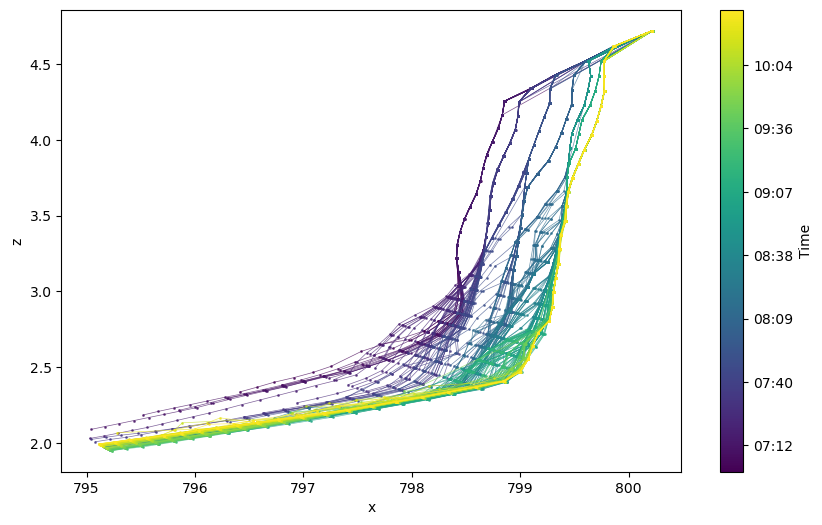

In [10]:
# PLOT FILTERED PROFILES
# prepare colormap normalized to time
times = pd.to_datetime(ds_filter_v1.t_window.values)
times_num = mdates.date2num(times)
norm = mpl.colors.Normalize(vmin=times_num.min(), vmax=times_num.max())
cmap = plt.cm.viridis

# optional: subsample time steps to avoid overplotting
n_steps = ds_filter_v1.sizes['t_window']
step = max(1, n_steps // 400)  # plot up to ~400 lines

fig, ax = plt.subplots(figsize=(10,6))

# plot lines on ax (subsample to avoid overplotting)
for j in range(0, n_steps, step):
    x = ds_filter_v1.x.values[:, j]
    z = ds_filter_v1.z.values[:, j]
    mask = ~np.isnan(x) & ~np.isnan(z)
    if mask.sum() < 2:
        continue
    color = cmap(norm(times_num[j]))
    ax.plot(x[mask], z[mask], '-o',color=color, linewidth=0.5, alpha=0.7, markersize=1)

# create mappable and attach colorbar to the axes
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])                    # required for colorbar
cbar = fig.colorbar(sm, ax=ax, label='Time')
cbar.ax.yaxis_date()
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax.set_xlabel('x'); ax.set_ylabel('z')
plt.show()

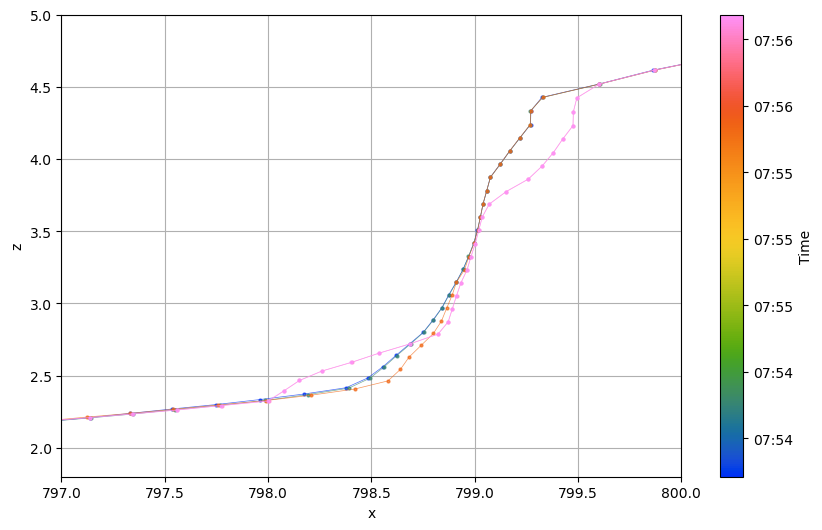

In [250]:
#ds_plot = ds_filter_v3.sel(t_window=slice('2024-12-19T14:15', '2024-12-19T17:50'))  # select specific time range for plotting
ds_plot = ds_filter_v3.sel(t_window=slice('2024-12-22T07:54', '2024-12-22T07:56'))  # select specific time range for plotting

# keep only timesteps with non-nan x
t_keep = ds_plot.t_window.values[~np.isnan(ds_plot.x.values).all(axis=0)]  # keep timesteps where not all x are nan
ds_plot = ds_plot.sel(t_window=t_keep)  # select only those timesteps

# prepare colormap normalized to time
times = pd.to_datetime(ds_plot.t_window.values)
times_num = mdates.date2num(times)
norm = mpl.colors.Normalize(vmin=times_num.min(), vmax=times_num.max())
cmap = plt.cm.viridis

cmap = plt.get_cmap('cet_CET_R1')

# optional: subsample time steps to avoid overplotting
n_steps = ds_plot.sizes['t_window']
step = 1#max(1, n_steps // 1000)  # plot up to ~400 lines

fig, ax = plt.subplots(figsize=(10,6))

# plot lines on ax (subsample to avoid overplotting)
for j in range(0, n_steps, step):
    x = ds_plot.x.values[:, j]
    z = ds_plot.z.values[:, j]
    mask = ~np.isnan(x) & ~np.isnan(z)
    if mask.sum() < 2:
        continue
    color = cmap(norm(times_num[j]))
    ax.plot(x[mask], z[mask], '-o',color=color, linewidth=0.5, alpha=0.7, markersize=2)

# create mappable and attach colorbar to the axes
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])                    # required for colorbar
cbar = fig.colorbar(sm, ax=ax, label='Time')
cbar.ax.yaxis_date()
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax.set_xlabel('x'); ax.set_ylabel('z')
ax.set_xlim([797, 800])
ax.set_ylim([1.8, 5])
ax.grid()
plt.show()

In [252]:
# TEST: FIND SLUMPING EVENTS
# parameters
window_size = 5  # number of consecutive points to check for slumping
dx_threshold = 0.03  # minimum horizontal distance in meters
slope_threshold = 0.7  # minimum slope (dz/dx) for slumping


ds_plot = ds_filter_v3
t_keep = ds_plot.t_window.values[~np.isnan(ds_plot.x.values).all(axis=0)]  # keep timesteps where not all x are nan
ds_plot = ds_plot.sel(t_window=t_keep)  # select only those timesteps

x = ds_plot.x                # dim (obs_number, t_window)
z = ds_plot.z

dx_t = x.diff(dim='t_window')    # change in time. shape (n_obs, n_t-1)
dx_x = x.diff(dim='obs_number')  # change in space. shape (n_obs-1, n_t)
dz_x = z.diff(dim='obs_number')  # change in space. shape (n_obs-1, n_t)
slope = dz_x / dx_x              # slope between consecutive points. shape (n_obs-1, n_t)
dx_logical = (dx_t > dx_threshold) & (slope > slope_threshold)       # logical mask where dx and slope are above threshold 

roll_sum = dx_logical.rolling(obs_number=window_size, min_periods=window_size).sum()   # 3) rolling sum along obs_number with window length 4
has_run = (roll_sum == window_size).any(dim='obs_number')   # Check if spatial window reached 4. Logical dataArray, shape (n_t-1)

# 5) timestamps corresponding to dx values (dx.t_window) — these correspond to intervals ending at t[1:]
t_dx = dx_t['t_window']            # use dx_t's time coordinatetime. NB: time after change
t_keep = t_dx[has_run]           # datetime values where condition is true
time_indices = np.nonzero(has_run.values)[0]   # integer indices into t_dx

z = ds_plot.z


In [254]:
t_keep

<xarray.DataArray 't_window' (t_window: 9)> Size: 72B
array(['2024-12-22T07:16:32.500000000', '2024-12-22T07:39:47.500000000',
       '2024-12-22T07:46:37.500000000', '2024-12-22T07:55:57.500000000',
       '2024-12-22T07:56:22.500000000', '2024-12-22T08:08:07.500000000',
       '2024-12-22T08:12:07.500000000', '2024-12-22T08:54:52.500000000',
       '2024-12-22T09:11:12.500000000'], dtype='datetime64[ns]')
Coordinates:
  * t_window  (t_window) datetime64[ns] 72B 2024-12-22T07:16:32.500000 ... 20...

(-2.0, 2.0)

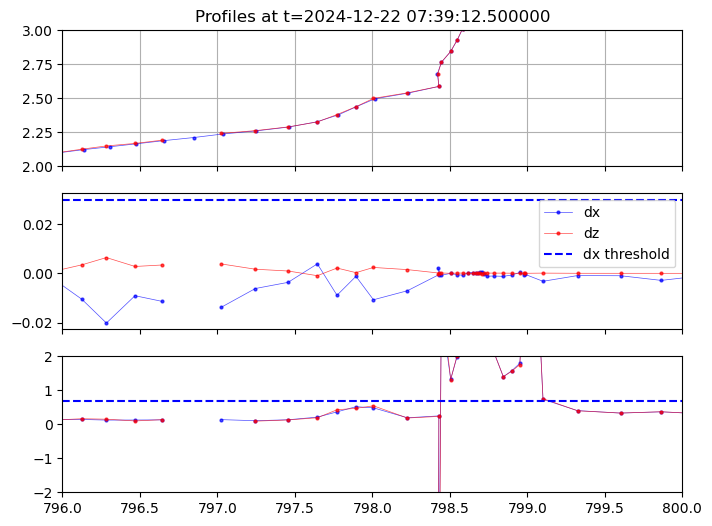

In [ ]:
fig, axs = plt.subplots(3,1,figsize=(8,6),sharex=True)
ii = ii-1
i = time_indices[ii]#+1
ax = axs[0]
ax.plot(x[:, i-1], ds_plot.z.values[:, i-1], '-o', color='blue', linewidth=0.5, alpha=0.7, markersize=2)
ax.plot(x[:, i], ds_plot.z.values[:, i], '-o', color='red', linewidth=0.5, alpha=0.7, markersize=2)
ax.set_title(f"Profiles at t={pd.to_datetime(ds_plot.t_window.values[i])}")
ax.grid()
ax.set_xlim([796, 800])
ax.set_ylim([2, 3])
 
ax = axs[1]
ax.plot(x[:, i], x[:,i] - x[:,i-1], '-o', color='blue', linewidth=0.5, alpha=0.7, markersize=2, label='dx')
ax.plot(x[:, i], z[:,i] - z[:,i-1], '-o', color='red',  linewidth=0.5, alpha=0.7, markersize=2, label='dz')  
ax.axhline(dx_threshold, color='blue', linestyle='--', label='dx threshold')
ax.legend()

ax = axs[2]
ax.plot(x[1:, i], slope[:,i-1], '-o', color='blue', linewidth=0.5, alpha=0.7, markersize=2, label='slope')
ax.plot(x[1:, i], slope[:,i], '-o', color='red', linewidth=0.5, alpha=0.7, markersize=2, label='slope')

ax.axhline(slope_threshold, color='blue', linestyle='--', label='slope threshold')
ax.set_ylim([-2,2])




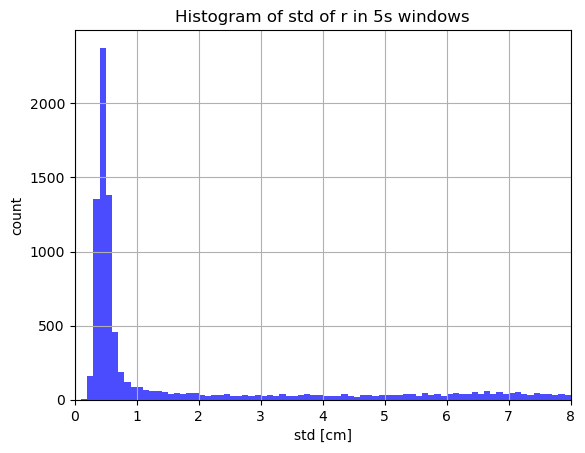

In [11]:
# MAKE HISTOGRAM OF STD OF r IN 5S WINDOWS, TO FIND THRESHOLD
sigma = r_std_5s[30:35, :].flatten() * 100  # take a few obs_number and flatten to 1D, convert to cm
sigma = r_std_5s[0:10, :].flatten() * 100  # take a few obs_number and flatten to 1D, convert to cm

plt.hist(sigma, bins=np.arange(0, 100, 0.1), density=False, alpha=0.7, color='blue')
plt.xlabel("std [cm]")
plt.ylabel("count")
plt.title("Histogram of std of r in 5s windows")
plt.xlim([0, 8])
plt.grid()
plt.show()
# CONCLUSION: 0.01 m seems a reasonable threshold: there is a clear drop in count after that

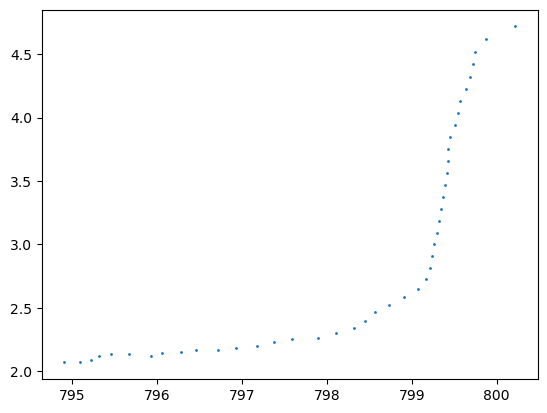

In [12]:
# plot x vs z for the first timestep
x = ds.x.values[:, 0]  # shape (obs_number,)
z = ds.z.values[:, 0]  # shape (obs_number,)
plt.scatter(x, z, s=1)


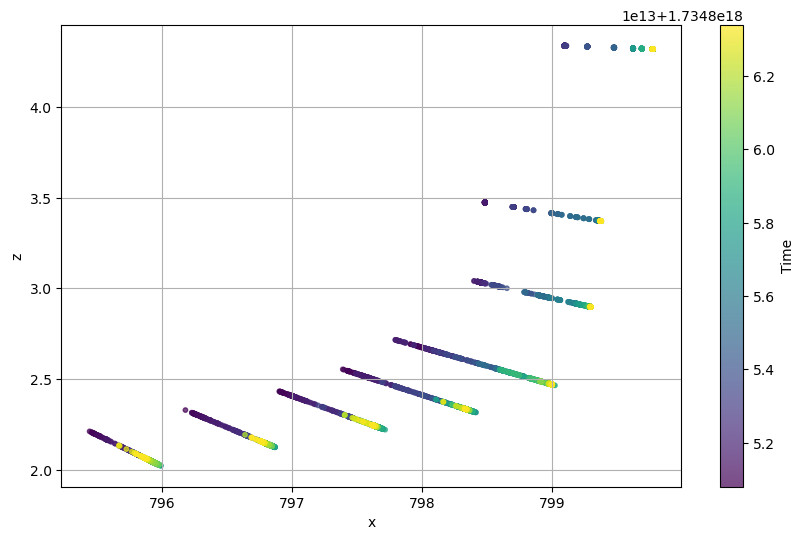

In [14]:
# MAKE A SCATTERPLOT OF X VS Z, COLORED BY TIME
ds_plot = ds_filter_v3#.sel(t_window=slice('2024-12-22T09:00', '2024-12-22T10:30'))  # select specific time range for plotting

# keep only timesteps with non-nan x
t_keep = ds_plot.t_window.values[~np.isnan(ds_plot.x.values).all(axis=0)]  # keep timesteps where not all x are nan
ds_plot = ds_plot.sel(t_window=t_keep)  # select only those timesteps

# flatten x, z, t 
i_plot  = np.array([5, 10, 14, 17, 20, 25, 30, 40])  # select specific obs_number for plotting
x = ds_plot.x[i_plot,:].values
z = ds_plot.z[i_plot,:].values
r = ds_plot.radius_lidar[i_plot,:].values
I = ds_plot.intensity[i_plot,:].values

x_flat = x.flatten()
z_flat = z.flatten()
t_flat = np.repeat(ds_plot.t_window.values[np.newaxis, :], i_plot.size, axis=0)  

fig, ax = plt.subplots(figsize=(10,6))
scatter = ax.scatter(x_flat, z_flat, c=t_flat, s=10, cmap='viridis', alpha=0.7)
ax.set_xlabel('x'); ax.set_ylabel('z')
ax.grid()
#ax.set_xlim([797.4, 797.7])
#ax.set_ylim([2.2, 2.35])

# Add colorbar
cbar = fig.colorbar(scatter, ax=ax, label='Time')
cbar.ax.yaxis_date()
#cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))


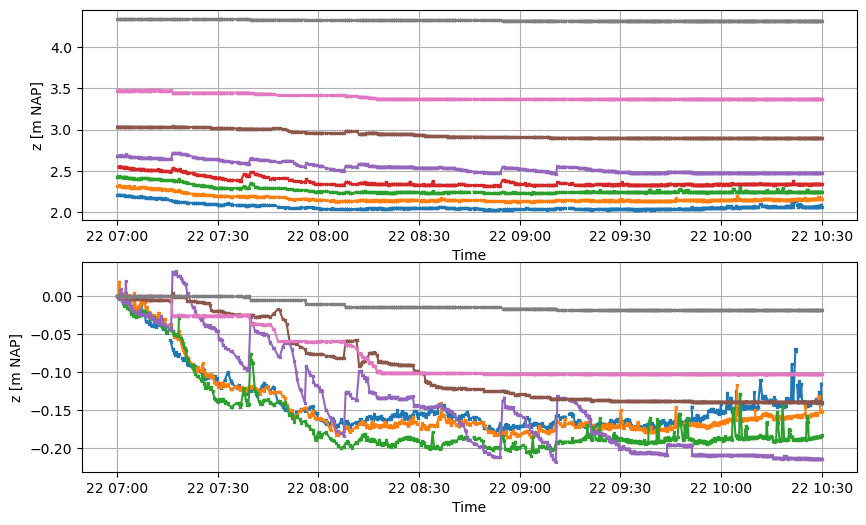

In [15]:
# PLOT TIME VS Z
fig, axs = plt.subplots(2, 1, figsize=(10,6))

# plot t vs z
ax = axs[0]
r = ds_plot.radius_lidar[i_plot,:].values
for i in range(r.shape[0]):
    ax.plot(ds_plot.t_window.values, z[i,:], '-x', markersize=2, label=f'obs_number {i_plot[i]}')
#r = z[0,:]
#ax.plot(ds_plot.t_window.values, r, label=f'obs_number {i_plot[2]}')
ax.set_xlabel('Time'); ax.set_ylabel('z [m NAP]')
#ax.legend()
ax.grid()

# plot t vs dz
ax = axs[1]
for i in range(r.shape[0]):
    ax.plot(ds_plot.t_window.values, z[i,:]-z[i,0], '-x', markersize=2, label=f'obs_number {i_plot[i]}')

ax.set_xlabel('Time'); ax.set_ylabel('z [m NAP]')
#ax.legend()
ax.grid()

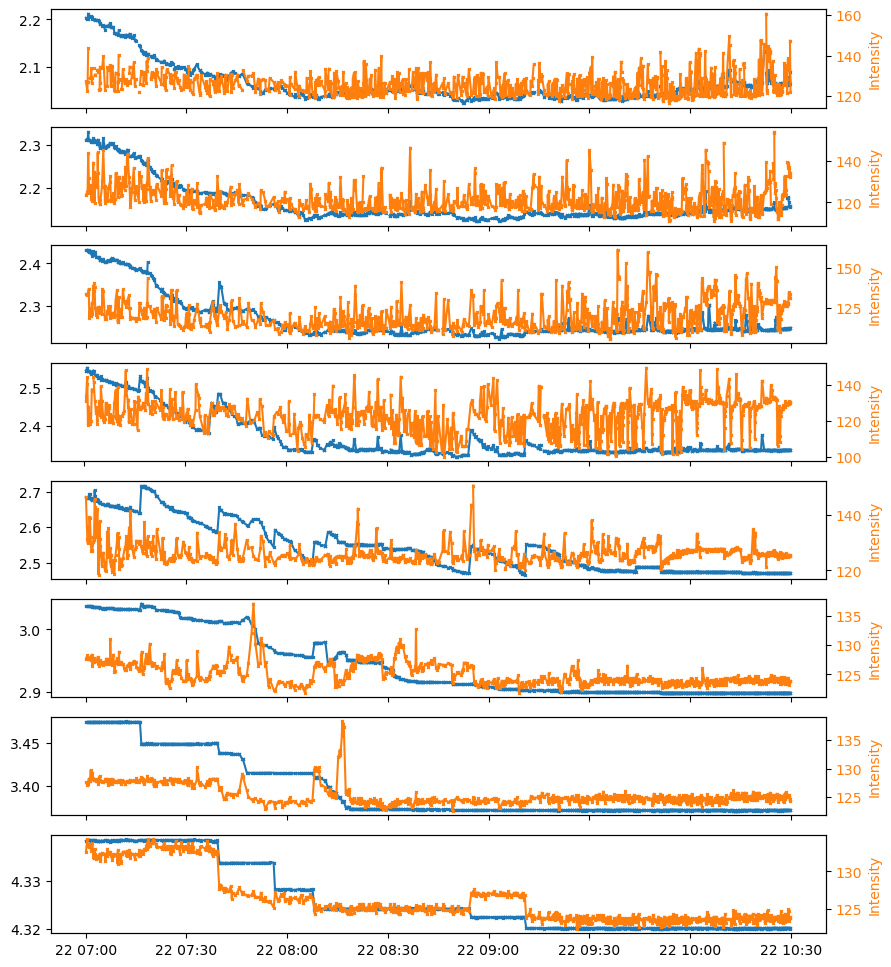

In [16]:
fig, axs = plt.subplots(8,1,figsize=(10,12))
for i in range(i_plot.size):
    ax=axs[i]
    ax.plot(ds_plot.t_window.values, z[i,:], '-x', markersize=2, label=f'obs_number {i_plot[i]}')

    # Secondary axis (right one)
    ax2 = ax.twinx()
    ax2.plot(ds_plot.t_window.values, I[i,:], '-x', markersize=2, color='tab:orange')
    ax2.set_ylabel('Intensity', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    # Remove x tick labels for all but the last subplot
    if i < i_plot.size - 1:
        ax.set_xticklabels([])
    #ax2.set_ylim([0, 100])


Text(0, 0.5, 'Intensity')

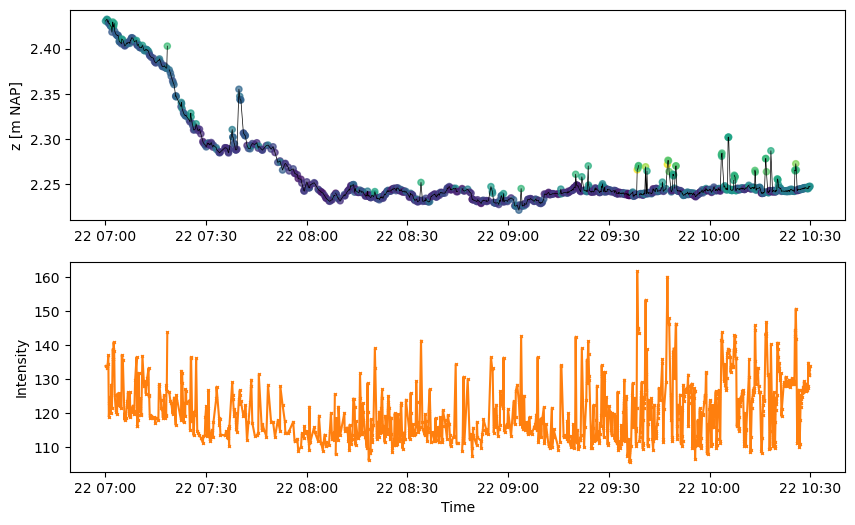

In [19]:
fig, ax = plt.subplots(2,1,figsize=(10,6))
i= i_plot[2]
ax[0].plot(t, z[i,:],linewidth=0.5, color='black' )
#ax.scatter(ds_plot.t_window.values, z[i,:], c=I[i,:], s=20, cmap='viridis', vmin=100, vmax=160,alpha=0.7)
ax[0].scatter(t, z[i,:], c=I[i,:], s=20, cmap='viridis',alpha=0.7)
ax[0].set_ylabel('z [m NAP]')
#ax[0].set_xlim([pd.Timestamp('22-12-2024 10:00'),  pd.Timestamp('22-12-2024 10:30')])

# second subplot
ax[1].plot(t, I[i,:], '-x', markersize=2, color='tab:orange')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Intensity')
#ax[1].set_xlim([pd.Timestamp('22-12-2024 10:00'),  pd.Timestamp('22-12-2024 10:30')])

In [72]:
i_plot

array([ 5, 10, 14, 17, 20, 25, 30, 40])

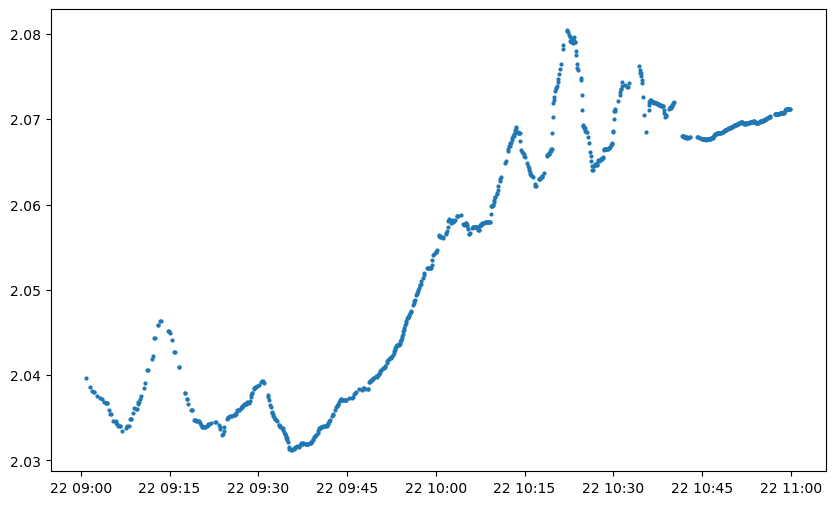

In [ ]:
# FILTER: CALCULATE MEAN, STD
z = ds_filter_v3.z
t = ds_filter_v3.t_window

# calculate rolling z_mean and z_std, over a window of 1 minute=12 observations
z_mean = z.rolling(t_window=12*5, center=True, min_periods=1).mean(skipna=True)
z_std  = z.rolling(t_window=12*5, center=True, min_periods=1).std(skipna=True)

# # only keep timesteps where z has a non-nan value
t_keep = ds_filter_v3.t_window.values[~np.isnan(ds_filter_v3.z.values).all(axis=0)]  # keep timesteps where not all x are nan
t_keep = ds_filter_v3.t_window.values[~np.isnan(ds_filter_v3.z.values).all(axis=0)]  # keep timesteps where not all x are nan
t = t.sel(t_window=t_keep)
z = z.sel(t_window=t_keep)
z_mean = z_mean.sel(t_window=t_keep)
z_std = z_std.sel(t_window=t_keep)

# filter: make z nan where |z-z_mean| > 1 cm AND > 1 std
mask_keep1 = np.abs(z - z_std) < 0.01 
mask_keep2 = z_std < 0.01
z_filtered = z.where(mask_keep1 | mask_keep2)  # keep where either condition is met


# plot t vs z_mean
i = i_plot[0]
plt.figure(figsize=(10,6))
#plt.plot(ds_filter_v3.t_window.values, z[i,:], '-x', markersize=2, label=f'obs_number {i_plot[0]}')
plt.plot(t, z_mean[i,:], 'o', markersize=2, label=f'obs_number {i_plot[0]}')


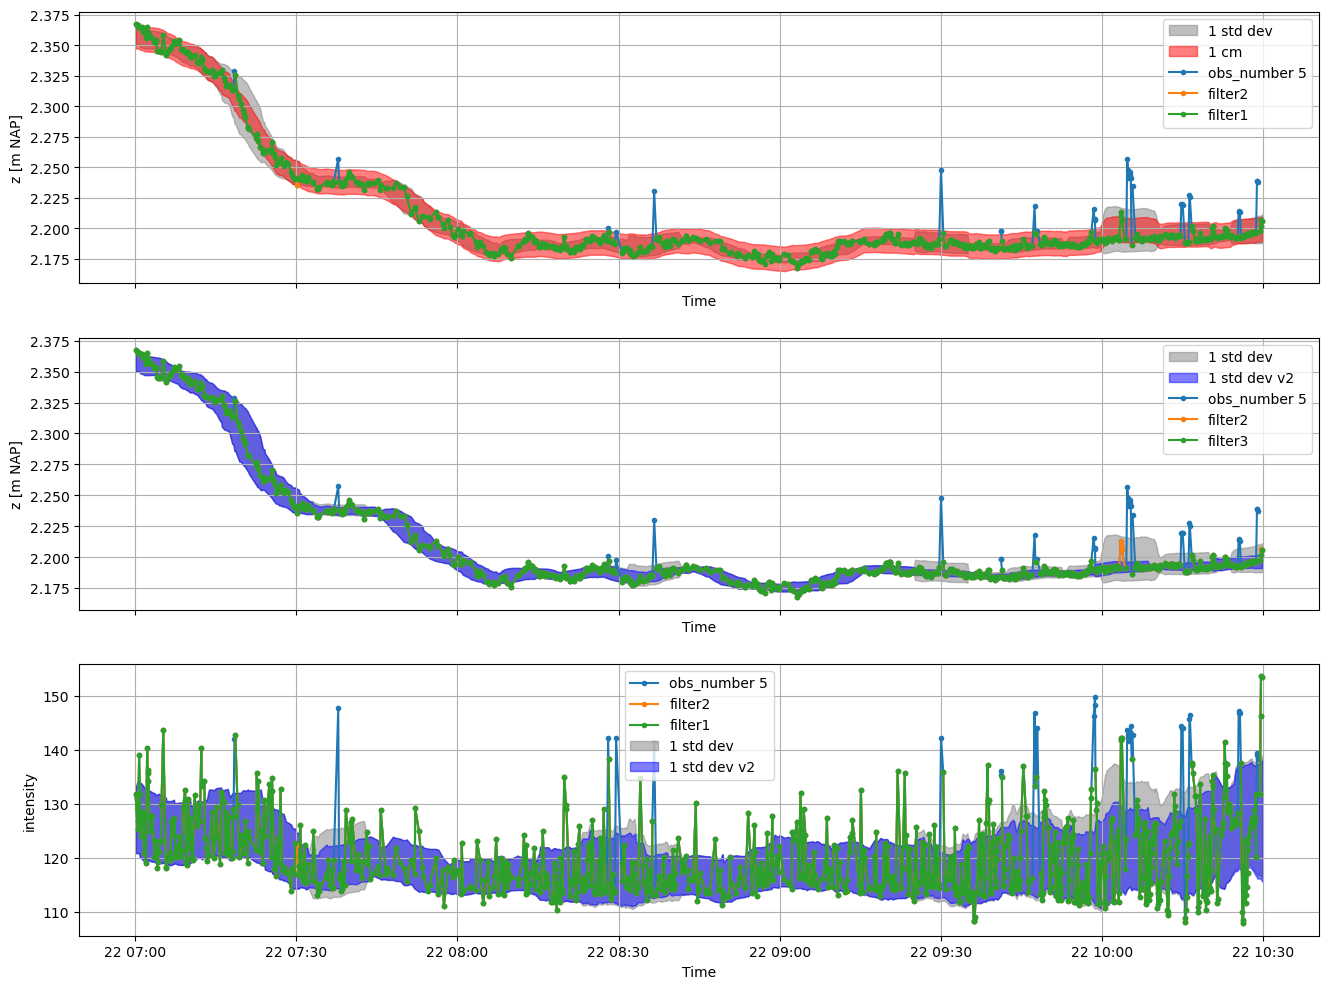

In [18]:
i = 12

window_minutes = 10
n_std_z = 1
n_std_z_pass1 = 2

n_std_I = 1

# FILTER: CALCULATE MEAN, STD. PLOT RANGE, OUTLIERS
z = ds_filter_v3.z
t = ds_filter_v3.t_window
I = ds_filter_v3.intensity

# # only keep timesteps where z has a non-nan value
t_keep = ds_filter_v3.t_window.values[~np.isnan(ds_filter_v3.z.values).all(axis=0)]  # keep timesteps where not all x are nan
t = t.sel(t_window=t_keep)

# Filter 1: remove worst outliers (>1cm, >2*std_z, >1*std_I) ----------------------------------------------
# calculate rolling z_mean and z_std, over a window of 1 minute=12 observations
z_mean = z.rolling(t_window=12*window_minutes, center=True, min_periods=1).mean(skipna=True)    # select timesteps after window, so that window length is correct
z_std  = z.rolling(t_window=12*window_minutes, center=True, min_periods=1).std(skipna=True)

I_mean = I.rolling(t_window=12*window_minutes, center=True, min_periods=1).mean(skipna=True)
I_std  = I.rolling(t_window=12*window_minutes, center=True, min_periods=1).std(skipna=True)

# filter: make z nan where |z-z_mean| > 1 cm AND > 1 std
mask_keep1 = np.abs(z - z_mean) < 0.01 
mask_keep2 = np.abs(z - z_mean) < n_std_z* z_std
mask_keep3 = np.abs(I - I_mean) < n_std_I* I_std

z_filtered1 = z.where(mask_keep1 | mask_keep2).sel(t_window=t_keep)  # keep where either condition is met
z_filtered_v2 = z.where(mask_keep1 | mask_keep2 | mask_keep3).sel(t_window=t_keep)

I_filtered1 = I.where(mask_keep1 | mask_keep2).sel(t_window=t_keep)
I_filtered_v2 = I.where(mask_keep1 | mask_keep2 | mask_keep3).sel(t_window=t_keep)

# Repeat, now with stricter filter ------------------------------------------------
# FILTER: CALCULATE MEAN, STD. PLOT RANGE, OUTLIERS

# filter: make z nan where |z-z_mean| > 1 cm AND > 2 std
mask_keep1 = np.abs(z - z_mean) < 0.01 
mask_keep2 = np.abs(z - z_mean) < n_std_z_pass1* z_std
mask_keep3 = np.abs(I - I_mean) < n_std_I* I_std

z_filtered_v3 = z.where(mask_keep1 | mask_keep2 | mask_keep3)  
I_filtered_v3 = I.where(mask_keep1 | mask_keep2 | mask_keep3)  

# calculate rolling z_mean and z_std, over a window of 1 minute=12 observations
z_mean2 = z_filtered_v3.rolling(t_window=12*window_minutes, center=True, min_periods=1).mean(skipna=True)
z_std2  = z_filtered_v3.rolling(t_window=12*window_minutes, center=True, min_periods=1).std(skipna=True)

I_mean2 = I_filtered_v3.rolling(t_window=12*window_minutes, center=True, min_periods=1).mean(skipna=True)
I_std2  = I_filtered_v3.rolling(t_window=12*window_minutes, center=True, min_periods=1).std(skipna=True)

# filter: make z nan where |z-z_mean| > 1 cm AND > 2 std
mask_keep1 = np.abs(z_filtered_v3 - z_mean2) < 0.01 
mask_keep2 = np.abs(z_filtered_v3 - z_mean2) < n_std_z* z_std2
mask_keep3 = np.abs(I_filtered_v3 - I_mean2) < n_std_I* I_std2

z_filtered_v3 = z_filtered_v3.where(mask_keep1 | mask_keep2 | mask_keep3).sel(t_window=t_keep)  # keep where either condition is met
I_filtered_v3 = I_filtered_v3.where(mask_keep1 | mask_keep2 | mask_keep3).sel(t_window=t_keep)  

# select timesteps
z = z.sel(t_window=t_keep)
z_mean = z_mean.sel(t_window=t_keep)
z_mean2 = z_mean2.sel(t_window=t_keep)
z_std = z_std.sel(t_window=t_keep)
z_std2 = z_std2.sel(t_window=t_keep)

I = I.sel(t_window=t_keep)
I_mean = I_mean.sel(t_window=t_keep)
I_std = I_std.sel(t_window=t_keep)
I_mean2 = I_mean2.sel(t_window=t_keep)
I_std2 = I_std2.sel(t_window=t_keep)

# plot t vs z with 1_std error bars ----------------------------------------
fig, axs = plt.subplots(3,1, figsize=(16,12), sharex=True)
ax=axs[0]
ax.fill_between(t, z_mean[i,:]-n_std_z*z_std[i,:], z_mean[i,:]+n_std_z*z_std[i,:], color='gray', alpha=0.5, label='1 std dev')
ax.fill_between(t, z_mean[i,:]-0.01, z_mean[i,:]+0.01, color='red', alpha=0.5, label='1 cm')
ax.plot(t, z[i,:], '-o', markersize=3, label=f'obs_number {i_plot[0]}')
ax.plot(t, z_filtered_v2[i,:], '-o', markersize=3, label='filter2' )
ax.plot(t, z_filtered1[i,:], '-o', markersize=3, label='filter1' )

ax.set_xlabel('Time'); ax.set_ylabel('z [m NAP]')
ax.legend()
ax.grid()

ax=axs[1] # subplot 2
ax.fill_between(t, z_mean[i,:]-n_std_z*z_std[i,:], z_mean[i,:]+n_std_z*z_std[i,:], color='gray', alpha=0.5, label='1 std dev')
ax.fill_between(t, z_mean2[i,:]-n_std_z*z_std2[i,:], z_mean2[i,:]+n_std_z*z_std2[i,:], color='blue', alpha=0.5, label='1 std dev v2')

ax.plot(t, z[i,:], '-o', markersize=3, label=f'obs_number {i_plot[0]}')
ax.plot(t, z_filtered_v2[i,:], '-o', markersize=3, label='filter2' )
ax.plot(t, z_filtered_v3[i,:], '-o', markersize=3, label='filter3' )

ax.set_xlabel('Time'); ax.set_ylabel('z [m NAP]')
ax.legend()
ax.grid()

ax=axs[2] # subplot 3
ax.plot(t, I[i,:], '-o', markersize=3, label=f'obs_number {i_plot[0]}')
ax.plot(t, I_filtered_v2[i,:], '-o', markersize=3, label='filter2' )
ax.plot(t, I_filtered1[i,:], '-o', markersize=3, label='filter1' )

ax.fill_between(t, I_mean[i,:]-n_std_I*I_std[i,:], I_mean[i,:]+n_std_I*I_std[i,:], color='gray', alpha=0.5, label='1 std dev')
ax.fill_between(t, I_mean2[i,:]-n_std_I*I_std2[i,:], I_mean2[i,:]+n_std_I*I_std2[i,:], color='blue', alpha=0.5, label='1 std dev v2')

ax.set_xlabel('Time'); ax.set_ylabel('z [m NAP]')
ax.legend()

ax.set_xlabel('Time'); ax.set_ylabel('intensity')
ax.grid()
#ax.set_xlim([pd.Timestamp('22-12-2024 10:30'),  pd.Timestamp('22-12-2024 10:45')])

In [2]:
folder = "C:\\Users\\dpoppema\\Documents\\lidar_processing"
filename = f"ds_profiles_corrected_lidar2_storm2.nc"
ds2 = xr.open_dataset(os.path.join(folder, filename))

ds2

<xarray.Dataset> Size: 663kB
Dimensions:                      (obs_number: 45, rotation_matrix_rows: 3,
                                  rotation_matrix_cols: 3, minute: 1141)
Coordinates:
  * obs_number                   (obs_number) int64 360B 0 1 2 3 ... 41 42 43 44
  * minute                       (minute) datetime64[ns] 9kB 2024-12-22T04:05...
    q                            int64 8B ...
Dimensions without coordinates: rotation_matrix_rows, rotation_matrix_cols
Data variables: (12/18)
    profile_angle                float32 4B ...
    beam_angle                   (obs_number) float64 360B ...
    rotation_matrix_lidar_to_RD  (rotation_matrix_rows, rotation_matrix_cols) float64 72B ...
    z_i                          float64 8B ...
    x_i_RD                       float64 8B ...
    y_i_RD                       float64 8B ...
    ...                           ...
    x                            (obs_number, minute) float32 205kB ...
    z                            (obs_number, minute) float32 205kB ...
    x_toe                        (minute) float64 9kB ...
    z_toe                        (minute) float64 9kB ...
    dune_area                    (minute) float64 9kB ...
    cliff_erosion                (minute) float64 9kB ...
Attributes: (12/14)
    name:                   storm2_lidar2_polar
    summary:                Hybrid Dune campaign, data of lidar 2 during storm 2
    instrument:             lidar 2
    period:                 storm 2, 2024-12-20 to 2024-12-23
    instrument type:        Sick Multiscan 165
    time zone:              UTC+1
    ...                     ...
    version:                v1
    version comments:       
    modification datetime:  13 Nov 2025 21:21
    dune_section:           S2 Sandy dune
    comment:                Pointcloud coordinates are stored in polar coordi...
    comment2:               Use rotation_matrix_lidar_to_RD, x_i_RD, y_i_RD, ...

(np.float64(20079.354166666668), np.float64(20079.395833333332))

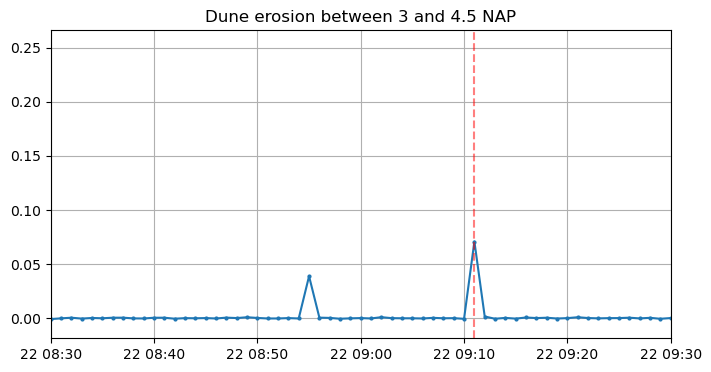

In [63]:
# Plot cliff erosion based on z_min=3
cliff_erosion = ds2.cliff_erosion
t_cliff = ds2.minute

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_cliff, cliff_erosion, '-o', markersize=2)
# plot a vertical line at every time step where cliff_erosion > 0.05
for t, erosion in zip(cliff_erosion.minute.values, cliff_erosion.values):
    if erosion > 0.05:
        ax.axvline(t, color='red', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title('Dune erosion between 3 and 4.5 NAP')
ax.set_xlim([pd.Timestamp('2024-12-22 08:30'), pd.Timestamp('2024-12-22 09:30')])

In [5]:
t_slumping = cliff_erosion.minute.values[cliff_erosion.values > 0.04]
t_slumping

array(['2024-12-22T07:17:00.000000000', '2024-12-22T07:40:00.000000000',
       '2024-12-22T07:56:00.000000000', '2024-12-22T08:08:00.000000000',
       '2024-12-22T09:11:00.000000000', '2024-12-22T19:20:00.000000000',
       '2024-12-22T19:56:00.000000000'], dtype='datetime64[ns]')

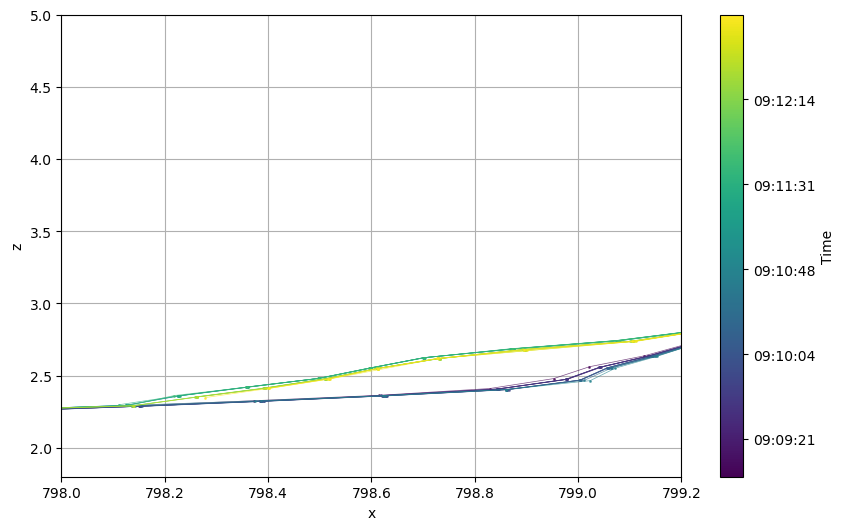

In [32]:
# plot profiles around slumping
t1 = t_slumping[4] - np.timedelta64(2, 'm')
t2 = t_slumping[4] + np.timedelta64(2, 'm')

ds_plot = ds_filter_v1.sel(t_window=slice(t1, t2))  # select specific time range for plotting

# prepare colormap normalized to time
times = pd.to_datetime(ds_plot.t_window.values)
times_num = mdates.date2num(times)
norm = mpl.colors.Normalize(vmin=times_num.min(), vmax=times_num.max())
cmap = plt.cm.viridis

# optional: subsample time steps to avoid overplotting
n_steps = ds_plot.sizes['t_window']
step = 1#max(1, n_steps // 400)  # plot up to ~400 lines

fig, ax = plt.subplots(figsize=(10,6))

# plot lines on ax (subsample to avoid overplotting)
for j in range(0, n_steps, step):
    x = ds_plot.x.values[:, j]
    z = ds_plot.z.values[:, j]
    mask = ~np.isnan(x) & ~np.isnan(z)
    if mask.sum() < 2:
        continue
    color = cmap(norm(times_num[j]))
    ax.plot(x[mask], z[mask], '-o',color=color, linewidth=0.5, alpha=0.7, markersize=1)

# create mappable and attach colorbar to the axes
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])                    # required for colorbar
cbar = fig.colorbar(sm, ax=ax, label='Time')
cbar.ax.yaxis_date()
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

ax.set_xlabel('x'); ax.set_ylabel('z')
ax.set_xlim([798, 799.2])
ax.set_ylim([1.8, 5])
ax.grid()
plt.show()

z = ds_plot.radius_lidar.values
ds_plot = ds_filter_v3.sel(t_window=slice(t1, t2))  # select specific time range for plotting
z2 = ds_plot.radius_lidar.values


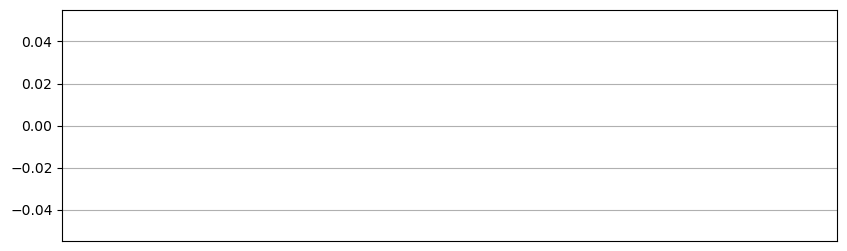

In [51]:
t1 = t_slumping[6] - np.timedelta64(2, 'm')
t2 = t_slumping[6] + np.timedelta64(2, 'm')

ds_plot = ds_filter_v1.sel(t_window=slice(t1, t2))  # select specific time range for plotting
z = ds_plot.radius_lidar.values
ds_plot = ds_filter_v3.sel(t_window=slice(t1, t2))  # select specific time range for plotting
z2 = ds_plot.radius_lidar.values

fig, ax = plt.subplots(figsize=(10,3))
ax.plot(z[33,:], '-k', markersize=3, label='filter2' )
ax.plot(z[34,:], '-k', markersize=3, label='filter2' )
ax.plot(z[35,:], '-k', markersize=3, label='filter2' )
ax.plot(z2[33,:], 'ok', markersize=3, label='filter2' )
ax.plot(z2[34,:], 'ok', markersize=3, label='filter2' )
ax.plot(z2[35,:], 'ok', markersize=3, label='filter2' )
ax.grid()

# x ticks every 5 x
ax.set_xticks(np.arange(0, z.shape[1], 5))

# minor grid every 1 x
ax.set_xticks(np.arange(0, z.shape[1], 1), minor=True)
ax.grid(which='minor', alpha=0.3)

# put x tick labels both above and below plot
ax.tick_params(axis='x', which='both', bottom=True, top=True, labelbottom=True, labeltop=True)